# Notebook 06 — Primeira Rede Neural com TensorFlow

## 🎯 Objetivos

Ao final deste notebook, você será capaz de:

- construir e compilar modelos com Keras;
- comparar arquiteturas e hiperparâmetros;
- separar treino, validação e teste;
- avaliar generalização e aplicar normalização.

> **Como estudar:** execute as células na ordem. Leia a explicação antes de cada bloco e compare os resultados obtidos com a interpretação apresentada.


importando tensorflow


In [1]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


Criar os dados:

In [2]:
import numpy as np

X = np.array([
    [1, 1],
    [2, 1],
    [1, 2],
    [2, 2],
    [3, 1],
    [1, 3]
], dtype=float)

y = np.array([
    [5],
    [7],
    [8],
    [10],
    [9],
    [11]
], dtype=float)

Criando a rede:

In [3]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(3, activation="relu"),
    tf.keras.layers.Dense(1)
])

Arquitetura:

         2 entradas
             │
             ▼
      ┌──────────────┐
      │ Dense(3)     │
      │ ReLU         │
      └──────┬───────┘
             │
             ▼
      ┌──────────────┐
      │ Dense(1)     │
      └──────┬───────┘
             │
             ▼
          Saída

Compilando:

In [4]:
model.compile(
    optimizer="adam",
    loss="mse"
)

Aqui estamos dizendo ao Keras:

Loss:
MSE

Otimizador:
Adam

O Adam é um algoritmo de otimização mais sofisticado que o Gradient Descent básico que implementamos.

Treinando o modelo:

In [5]:
history = model.fit(
    X,
    y,
    epochs=500,
    verbose=1
)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 79.8029
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 79.6174
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 79.4321
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 79.2471
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 79.0623
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 78.8778
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 78.6935
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 78.5094
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 78.3256
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 78.1421
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 77.9588
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 77.7758
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 77.5930
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 77.4105
Epoch 15/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 77.2283
Epoch 

O código a cima substitui dezenas de linhas do nosso código manual por uma API de alto nível.

fazendo previsão:

In [6]:
nova_entrada = np.array([
    [4, 2]
], dtype=float)

previsao = model.predict(nova_entrada)

print("Previsão:", previsao)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Previsão: [[8.216718]]


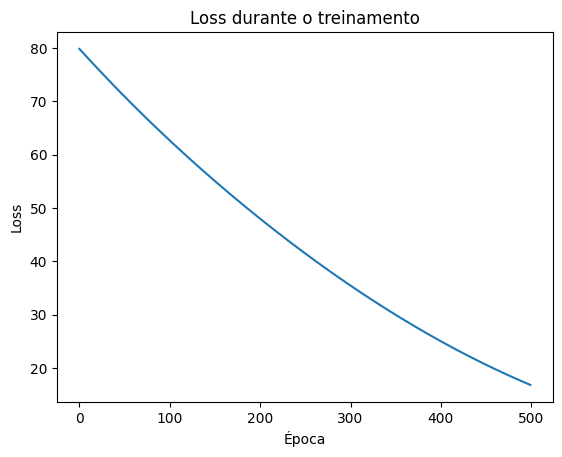

In [7]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"])

plt.xlabel("Época")
plt.ylabel("Loss")

plt.title("Loss durante o treinamento")

plt.show()

O modelo precisa de mais treinamento para chegar mais perto do 0

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(3, activation="relu"),
    tf.keras.layers.Dense(1)
])

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="mse"
)

In [10]:
history = model.fit(
    X,
    y,
    epochs=2000,
    verbose=0
)

In [11]:
previsao = model.predict(
    np.array([[4, 2]], dtype=float),
    verbose=0
)

print("Previsão:", previsao)
print("Loss final:", history.history["loss"][-1])

Previsão: [[13.983195]]
Loss final: 2.5519599148537964e-05


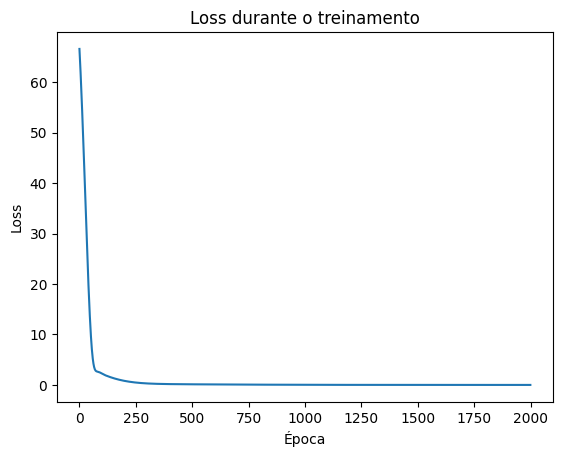

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"])

plt.xlabel("Época")
plt.ylabel("Loss")

plt.title("Loss durante o treinamento")

plt.show()

agora sem a função sem relu:

In [13]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(3),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="mse"
)

history = model.fit(
    X,
    y,
    epochs=1000,
    verbose=0
)

previsao = model.predict(
    np.array([[4, 2]], dtype=float),
    verbose=0
)

print("Previsão:", previsao)
print("Loss final:", history.history["loss"][-1])

Previsão: [[13.924102]]
Loss final: 0.0005088127800263464


A ReLU introduz uma não linearidade.

É isso que permite que redes neurais profundas aprendam relações muito mais complexas.

Agora vamos utilizar 1.000 exemplos e criar um dataset e separar 700 para treino 150 para testes e 150 para validações

In [14]:
import numpy as np
import matplotlib.pyplot as plt

Vamos usar uma semente para que os resultados sejam reproduzíveis:

In [15]:
np.random.seed(42)

Isso significa que, sempre que executarmos o código novamente, teremos os mesmos dados aleatórios.

Criar as entradas

Vamos gerar 1.000 exemplos.

Cada exemplo terá duas características:

x₁

x₂

In [16]:
X = np.random.uniform(
    0,
    10,
    size=(1000, 2)
)

Isso gera uma matriz:

1000 × 2

Ou seja:

1000 exemplos

2 características

In [17]:
print("Shape de X:", X.shape)
print("\nPrimeiros 5 exemplos:")
print(X[:5])

Shape de X: (1000, 2)

Primeiros 5 exemplos:
[[3.74540119 9.50714306]
 [7.31993942 5.98658484]
 [1.5601864  1.5599452 ]
 [0.58083612 8.66176146]
 [6.01115012 7.08072578]]


Criar os valores reais

Agora vamos criar o nosso alvo.

A fórmula será:

y = 2x₁ + 3x₂

Em Python:

In [18]:
y = (
    2 * X[:, 0]
    + 3 * X[:, 1]
)

Como queremos trabalhar com redes neurais, vamos transformar y em uma matriz de uma coluna:

In [19]:
y = y.reshape(-1, 1)

In [20]:
print("Shape de y:", y.shape)
print("\nPrimeiros 5 valores:")
print(y[:5])

Shape de y: (1000, 1)

Primeiros 5 valores:
[[36.01223157]
 [32.59963336]
 [ 7.80020842]
 [27.14695662]
 [33.26447757]]


Adicionando ruído

Agora vamos fazer algo interessante.

Dados reais normalmente não seguem uma fórmula perfeita.

Por exemplo:

Preço de uma casa

Salário

Consumo de energia

Vendas

Temperatura

Sempre existem fatores que não conseguimos explicar perfeitamente.

Vamos simular isso:

In [21]:
ruido = np.random.normal(
    0,
    1,
    size=(1000, 1)
)

In [22]:
y = y + ruido

Nossa relação agora é aproximadamente:

y ≈ 2x₁ + 3x₂

mas com pequenas variações.

Verificar os dados

In [23]:
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

print("\nPrimeiros 5 exemplos:")

for i in range(5):
    print(
        f"X: {X[i]} → y: {y[i][0]:.2f}"
    )

Shape de X: (1000, 2)
Shape de y: (1000, 1)

Primeiros 5 exemplos:
X: [3.74540119 9.50714306] → y: 35.13
X: [7.31993942 5.98658484] → y: 31.77
X: [1.5601864 1.5599452] → y: 7.57
X: [0.58083612 8.66176146] → y: 27.51
X: [6.01115012 7.08072578] → y: 34.18


Visualizar o relacionamento

Vamos visualizar a relação entre x₁ e y.

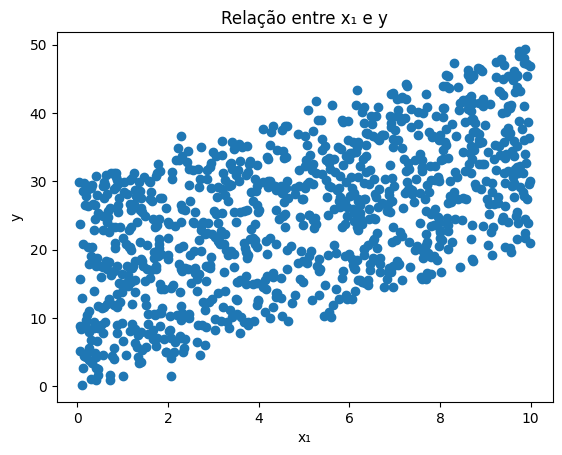

In [24]:
plt.scatter(
    X[:, 0],
    y
)

plt.xlabel("x₁")
plt.ylabel("y")

plt.title("Relação entre x₁ e y")

plt.show()

Depois podemos fazer o mesmo para x₂:

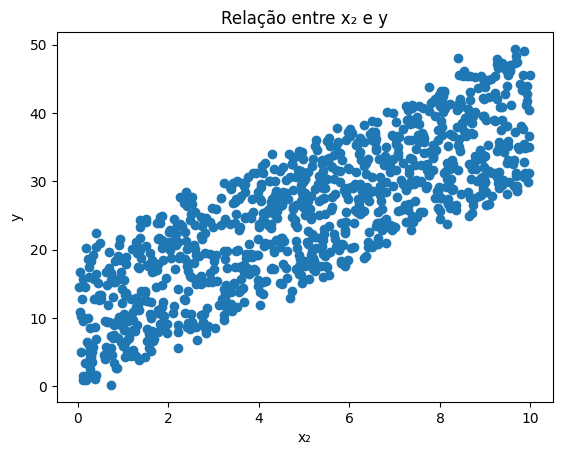

In [25]:
plt.scatter(
    X[:, 1],
    y
)

plt.xlabel("x₂")
plt.ylabel("y")

plt.title("Relação entre x₂ e y")

plt.show()

Quanto maior x₁
       ↓
Maior y

e:

Quanto maior x₂
       ↓
Maior y

Isso acontece porque:

y = 2x₁ + 3x₂

Agora vamos separar os dados

Agora temos:

1000 exemplos

Vamos separar:

70% → Treinamento
15% → Validação
15% → Teste

Isso corresponde a:

700 exemplos → Treino
150 exemplos → Validação
150 exemplos → Teste

Primeiro vamos embaralhar os índices:

In [26]:
indices = np.random.permutation(len(X))

calculando os tamanhos

In [27]:
train_size = int(0.70 * len(X))
val_size = int(0.15 * len(X))

separando os índices

In [28]:
train_indices = indices[:train_size]

val_indices = indices[
    train_size:
    train_size + val_size
]

test_indices = indices[
    train_size + val_size:
]

criando os conjuntos:

In [29]:
X_train = X[train_indices]
y_train = y[train_indices]

X_val = X[val_indices]
y_val = y[val_indices]

X_test = X[test_indices]
y_test = y[test_indices]

conferindo a divisão:

In [30]:
print("Treinamento:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nValidação:")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\nTeste:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Treinamento:
X_train: (700, 2)
y_train: (700, 1)

Validação:
X_val: (150, 2)
y_val: (150, 1)

Teste:
X_test: (150, 2)
y_test: (150, 1)


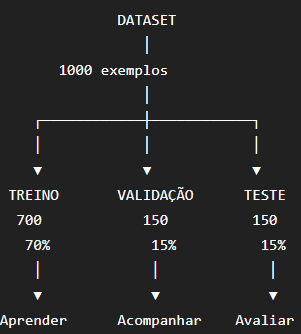

Treinando com Treino + Validação

Agora vamos criar uma rede um pouco maior.

Anteriormente usamos:

2 → 3 → 1

Agora vamos usar:

2 → 16 → 8 → 1

Visualmente:

              ENTRADA
             2 valores
                 │
                 ▼
          ┌─────────────┐
          │ Dense(16)   │
          │ ReLU        │
          └──────┬──────┘
                 │
                 ▼
          ┌─────────────┐
          │ Dense(8)    │
          │ ReLU        │
          └──────┬──────┘
                 │
                 ▼
          ┌─────────────┐
          │ Dense(1)    │
          └──────┬──────┘
                 │
                 ▼
               SAÍDA

Essa rede tem muito mais capacidade do que precisamos para resolver:

y ≈ 2x₁ + 3x₂

E isso é proposital.

Vamos começar a entender como um modelo mais complexo se comporta.

In [31]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1)
])

Entrada
  ↓
Dense(16) + ReLU
  ↓
Dense(8) + ReLU
  ↓
Dense(1)
  ↓
Saída

In [32]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.01
    ),
    loss="mse"
)

Optimizer → Adam
Learning Rate → 0.01
Loss → MSE

Treinar usando validação

In [33]:
history = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=200,

    verbose=1
)

Epoch 1/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 476.3984 - val_loss: 236.5111
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 78.0260 - val_loss: 24.8638
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 16.9409 - val_loss: 9.5082
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.1492 - val_loss: 2.6022
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.9575 - val_loss: 1.3435
Epoch 6/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.4355 - val_loss: 1.2454
Epoch 7/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.2372 - val_loss: 1.0910
Epoch 8/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.2164 - val_loss: 1.1080
Epoch 9/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.1249 - val_loss: 1.2296
Epoch 10/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.1936 - val_loss: 1.1873
Epoch 11/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.1097 - val_loss: 1.0615
Epoch 12/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - l

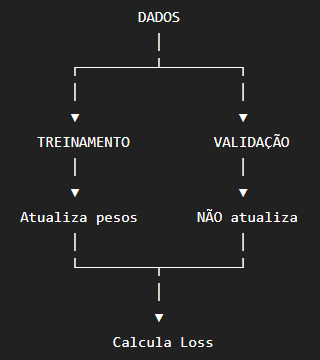

A validação serve apenas para verificar como o modelo está se comportando com dados que não estão sendo usados diretamente para atualizar os pesos.

Visualizar Training Loss e Validation Loss

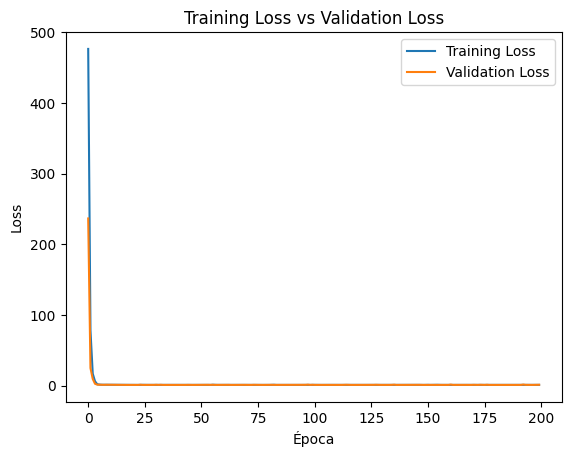

In [34]:
plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Época")
plt.ylabel("Loss")

plt.title(
    "Training Loss vs Validation Loss"
)

plt.legend()

plt.show()

In [35]:
test_loss = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)

Test Loss: 1.0091757774353027


Esse é o resultado final do modelo em dados que ele nunca viu durante o treinamento.

In [36]:
novas_entradas = np.array([
    [4, 2],
    [5, 3],
    [10, 1],
    [2, 5],
    [7, 4]
], dtype=float)

In [37]:
previsoes = model.predict(
    novas_entradas,
    verbose=0
)

print("Entradas:")
print(novas_entradas)

print("\nPrevisões:")
print(previsoes)

Entradas:
[[ 4.  2.]
 [ 5.  3.]
 [10.  1.]
 [ 2.  5.]
 [ 7.  4.]]

Previsões:
[[14.272278]
 [19.32558 ]
 [23.307835]
 [19.302555]
 [26.40482 ]]


Criando um modelo menor:

In [40]:
model_small = tf.keras.Sequential([
    tf.keras.layers.Dense(
        4,
        activation="relu"
    ),
    tf.keras.layers.Dense(1)
])

In [41]:
model_small.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.01
    ),
    loss="mse"
)

In [42]:
history_small = model_small.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=200,

    verbose=0
)

In [43]:
test_loss_small = model_small.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(
    "Test Loss modelo pequeno:",
    test_loss_small
)

Test Loss modelo pequeno: 0.8655192255973816


Modelo grande

Test Loss ≈ 1.009

Modelo pequeno

Test Loss ≈ 0.866

Nesse caso, o modelo pequeno venceu.

Não podemos afirmar:

"O modelo 2 → 4 → 1 é sempre melhor."

O que podemos afirmar é:

Para este experimento específico, com este dataset, este treinamento e esta divisão dos dados, o modelo pequeno obteve melhor desempenho no conjunto de teste.

Isso é uma distinção muito importante em Machine Learning.

Se você treinasse novamente, poderia obter resultados diferentes por causa da inicialização aleatória.

Por isso, em projetos mais sérios, podemos usar técnicas como:

validação cruzada;
múltiplas execuções;
busca de hiperparâmetros;
regularização.

Normalização

Agora vamos para um conceito fundamental antes de começarmos a trabalhar com datasets reais.

Normalização de dados

Imagine que nosso dataset tivesse:

Idade       → 18 até 80

Salário     → 1.500 até 50.000

Patrimônio  → 10.000 até 10.000.000

Se colocarmos esses valores diretamente em uma rede:

18

50000

10000000

as características estão em escalas completamente diferentes.

Isso pode dificultar o treinamento.

Queremos transformar algo como:

18

50000

10000000

em valores em uma escala mais equilibrada.

Por exemplo:

0.2

0.5

0.8

Vamos estudar dois métodos:

1. Min-Max Scaling
2. Standardization (Z-Score)

E entender quando usar cada um.

Min-Max Scaling

In [44]:
X_original = X.copy()

In [45]:
X_min = X.min(axis=0)
X_max = X.max(axis=0)

X_normalizado = (
    X - X_min
) / (
    X_max - X_min
)

In [46]:
print("Mínimos:")
print(X_min)

print("\nMáximos:")
print(X_max)

print("\nPrimeiros 5 dados originais:")
print(X_original[:5])

print("\nPrimeiros 5 dados normalizados:")
print(X_normalizado[:5])

Mínimos:
[0.04939981 0.03218264]

Máximos:
[9.99413726 9.99717673]

Primeiros 5 dados originais:
[[3.74540119 9.50714306]
 [7.31993942 5.98658484]
 [1.5601864  1.5599452 ]
 [0.58083612 8.66176146]
 [6.01115012 7.08072578]]

Primeiros 5 dados normalizados:
[[0.37165399 0.95082449]
 [0.73109417 0.59753194]
 [0.1519182  0.15331294]
 [0.05343895 0.86598936]
 [0.59948795 0.70733039]]


Na prática, não devemos normalizar o dataset inteiro antes de separar treino e teste.

O correto é:

Dataset

   │

   ▼

Separar Train / Validation / Test

   │

   ▼

Calcular parâmetros usando apenas Train

   │

   ├── Transformar Train

   ├── Transformar Validation
   
   └── Transformar Test

Por quê?

Porque se usarmos o dataset inteiro para calcular:

In [47]:
X.min()
X.max()

np.float64(9.997176732861305)

In [48]:
X_train_min = X_train.min(axis=0)
X_train_max = X_train.max(axis=0)

In [49]:
X_train_norm = (
    X_train - X_train_min
) / (
    X_train_max - X_train_min
)

In [50]:
X_val_norm = (
    X_val - X_train_min
) / (
    X_train_max - X_train_min
)

X_test_norm = (
    X_test - X_train_min
) / (
    X_train_max - X_train_min
)

Calcular os limites usando apenas o treino

In [51]:
X_train_min = X_train.min(axis=0)
X_train_max = X_train.max(axis=0)

print("Mínimo do treino:")
print(X_train_min)

print("\nMáximo do treino:")
print(X_train_max)

Mínimo do treino:
[0.04939981 0.04632023]

Máximo do treino:
[9.96334338 9.99717673]


Normalizar o conjunto de treinamento

In [52]:
X_train_norm = (
    X_train - X_train_min
) / (
    X_train_max - X_train_min
)

In [53]:
print("Primeiros 5 dados normalizados:")
print(X_train_norm[:5])

Primeiros 5 dados normalizados:
[[0.66890148 0.20134174]
 [0.27839026 0.54072135]
 [0.29514841 0.56315752]
 [0.55492042 0.73203676]
 [0.58373959 0.07346364]]


Normalizar validação

In [54]:
X_val_norm = (
    X_val - X_train_min
) / (
    X_train_max - X_train_min
)

Normalizar teste

In [55]:
X_test_norm = (
    X_test - X_train_min
) / (
    X_train_max - X_train_min
)

Agora temos:

X_train_norm

X_val_norm

X_test_norm

Conferir as dimensões

In [56]:
print("X_train_norm:", X_train_norm.shape)
print("X_val_norm:", X_val_norm.shape)
print("X_test_norm:", X_test_norm.shape)

X_train_norm: (700, 2)
X_val_norm: (150, 2)
X_test_norm: (150, 2)


Criar um novo modelo

Agora vamos testar novamente nosso modelo pequeno:

2 → 4 → 1

In [57]:
model_norm = tf.keras.Sequential([
    tf.keras.layers.Dense(
        4,
        activation="relu"
    ),
    tf.keras.layers.Dense(1)
])

In [58]:
model_norm.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.01
    ),
    loss="mse"
)

In [59]:
history_norm = model_norm.fit(
    X_train_norm,
    y_train,

    validation_data=(
        X_val_norm,
        y_val
    ),

    epochs=200,

    verbose=0
)

In [60]:
test_loss_norm = model_norm.evaluate(
    X_test_norm,
    y_test,
    verbose=0
)

print(
    "Test Loss com normalização:",
    test_loss_norm
)

Test Loss com normalização: 0.8567274212837219


In [61]:
print(
    "Sem normalização:",
    test_loss_small
)

print(
    "Com normalização:",
    test_loss_norm
)

Sem normalização: 0.8655192255973816
Com normalização: 0.8567274212837219


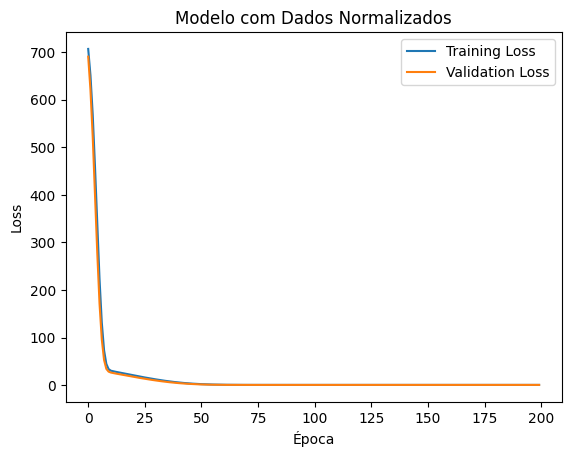

In [62]:
plt.plot(
    history_norm.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_norm.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Época")
plt.ylabel("Loss")

plt.title(
    "Modelo com Dados Normalizados"
)

plt.legend()

plt.show()

## ✅ Síntese do Notebook 06

Neste notebook, passamos da implementação manual para o Keras. Os principais aprendizados foram:

- `Sequential` organiza camadas em sequência;
- `Dense` implementa `XW + b` e uma ativação opcional;
- `compile` define otimizador, loss e métricas;
- `fit` executa o treinamento e registra o histórico;
- validação ajuda a escolher modelos sem usar o teste;
- normalização pode facilitar a otimização;
- uma rede maior nem sempre generaliza melhor que uma menor.

### Checklist de modelagem

- [ ] Separei treino, validação e teste?
- [ ] Ajustei o normalizador somente com o treino?
- [ ] Comparei training loss e validation loss?
- [ ] Avaliei o modelo final apenas no teste?
- [ ] Registrei arquitetura e hiperparâmetros?

### Próximo notebook

No Notebook 07, aplicaremos o fluxo completo a um dataset real de preços de imóveis da Califórnia.
